# Preprocessing Utilities

Utility functions for downloading, preparing, and loading the Chinese MNIST dataset.

Features
--------
* Dataset preparation: download (if missing), unzip, stratified split into train/val/test.
* Transform builders: consistent preprocessing / augmentation pipelines for each split.
* DataLoader factory: ``ImageFolder`` datasets wrapped in PyTorch ``DataLoader`` objects.
* Visualization helpers: quick dataset summaries and sample image previews.

Defaults target 64×64 grayscale images with **light train‑time augmentation** (rotation + small translation) and
no normalization (unless explicitly enabled). All transforms can optionally flatten tensors for fully connected
architectures (e.g., logistic regression / MLP) or keep spatial layout (set ``flatten=False`` for CNNs).

Dataset already exists, skipping download.
Train/Val/Test folders already exist. (Set overwrite=True to recreate them)
Dataset ready at: data
train: 12000 images, 15 classes
{'0': 800, '1': 800, '10': 800, '100': 800, '1000': 800, '10000': 800, '100000000': 800, '2': 800, '3': 800, '4': 800, '5': 800, '6': 800, '7': 800, '8': 800, '9': 800}
val: 1500 images, 15 classes
{'0': 100, '1': 100, '10': 100, '100': 100, '1000': 100, '10000': 100, '100000000': 100, '2': 100, '3': 100, '4': 100, '5': 100, '6': 100, '7': 100, '8': 100, '9': 100}
test: 1500 images, 15 classes
{'0': 100, '1': 100, '10': 100, '100': 100, '1000': 100, '10000': 100, '100000000': 100, '2': 100, '3': 100, '4': 100, '5': 100, '6': 100, '7': 100, '8': 100, '9': 100}


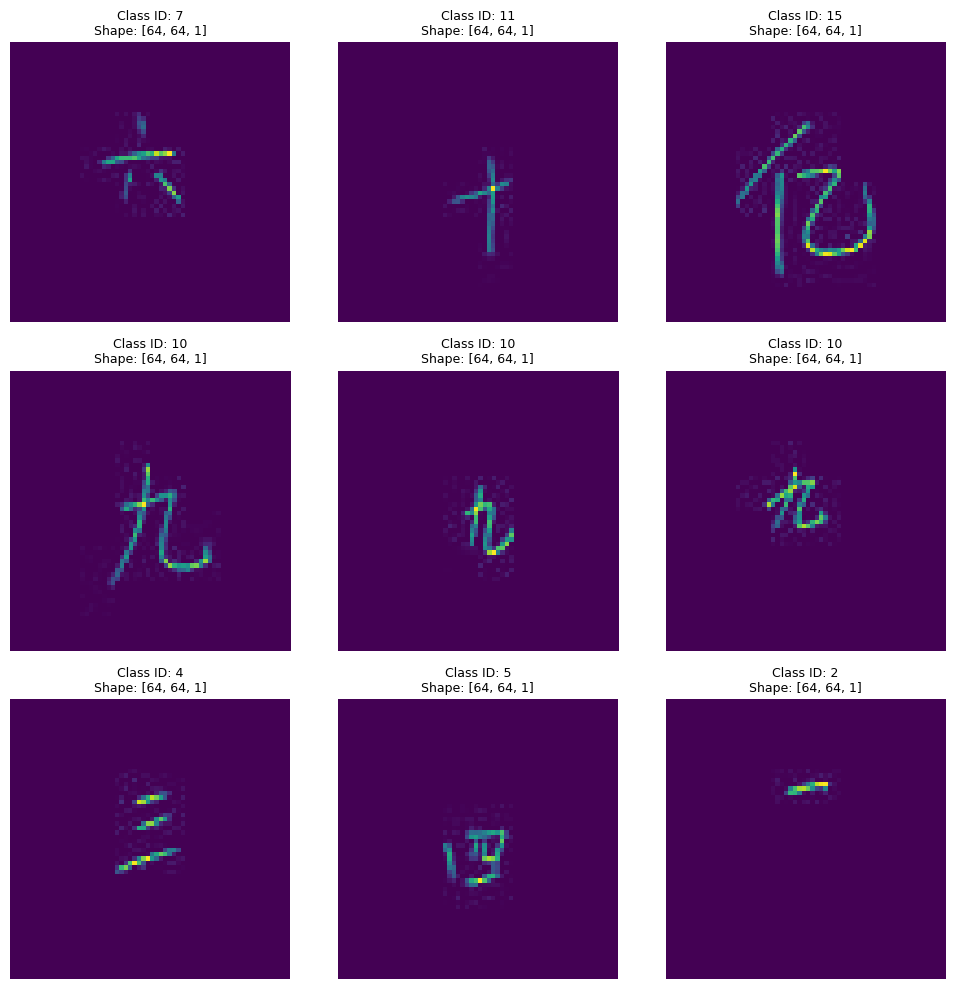

DataLoaders ready.


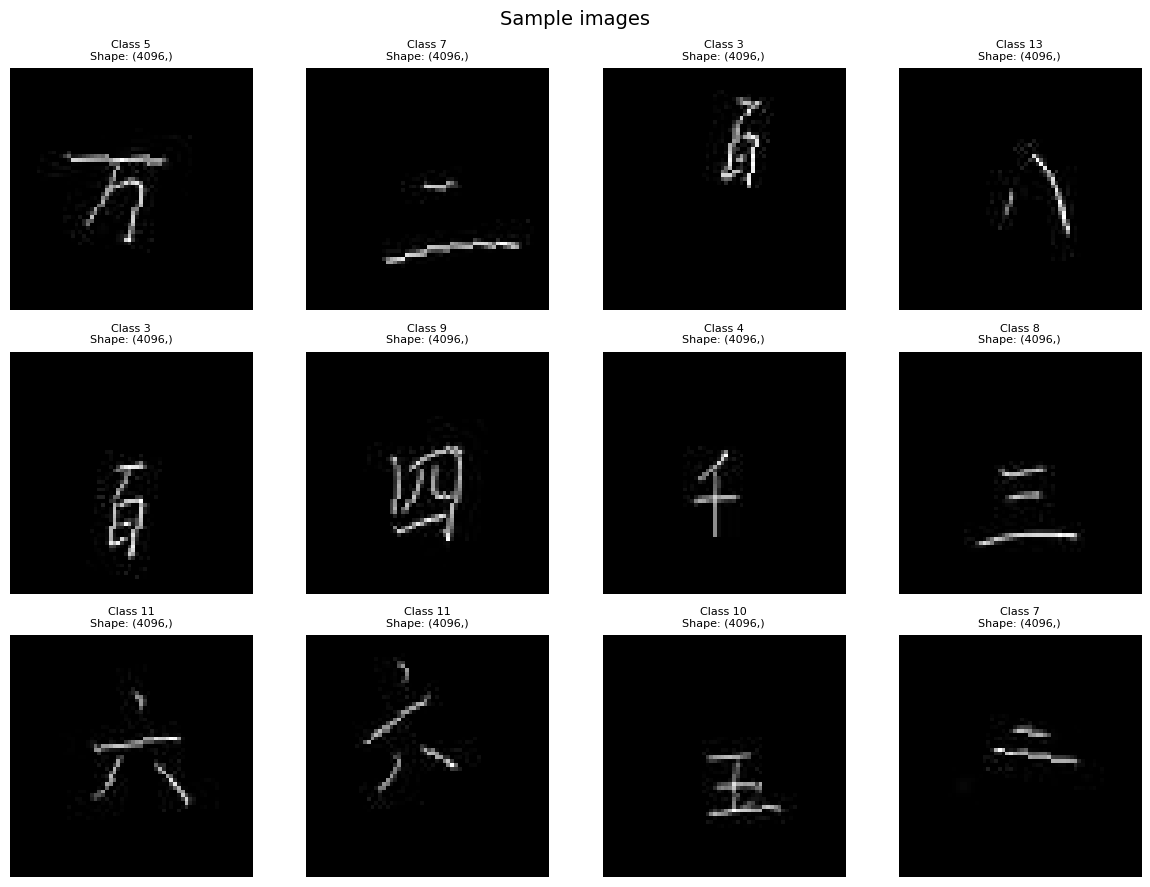

In [1]:
import zipfile
import shutil
import random
from pathlib import Path
from typing import Any, Dict, List, Tuple
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import DataLoader
from torchvision import datasets as tvds, transforms


def prepare_images(
        url: str = "https://github.com/emilianodesu/MLA2/raw/main/data.zip",
        data_dir: str | Path = "data",
        split_ratio: Tuple[float, float, float] = (0.8, 0.1, 0.1),
        overwrite: bool = False,
        label_type: str = "value"
) -> Path:
    """
    Download, extract, and split the Chinese MNIST dataset into train/val/test folders.

    Behavior
    - If `data/c_mnist` and the metadata CSV already exist, the download/extract step is skipped.
    - If train/val/test folders already exist and `overwrite=False`, the split step is skipped.
    - Splits are stratified by the selected label to preserve class balance (random_state=42).

    Args:
        url: Remote URL to the dataset archive (zip). Used only when the dataset is missing.
        data_dir: Root data directory. Images and splits will live under this folder.
        split_ratio: (train, val, test) ratios. Must sum to 1.0.
        overwrite: When True, removes existing split folders before re-creating them.
        label_type: Which label to use for classification.
            - "value": use the numeric digit value as the class.
            - "value_character": use a composite label "<value>_<character>".
            - "code": use the code id.

    Returns:
        Path: The resolved `data_dir` as a Path object.

    Raises:
        AssertionError: If `split_ratio` does not sum to 1.0 (within numerical tolerance).
        FileNotFoundError: If the expected CSV or images are missing after extraction.
    """
    data_path = Path(data_dir)
    image_path = data_path / "c_mnist"
    csv_path = data_path / "chinese_mnist.csv"
    zip_path = "data.zip"

    # Check existence of dataset
    if image_path.is_dir() and csv_path.is_file():
        print("Dataset already exists, skipping download.")
    else:
        print("Dataset not found, downloading...")
        data_path.mkdir(parents=True, exist_ok=True)

        # Download
        response = requests.get(url, stream=True, timeout=30)
        with open(zip_path, "wb") as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)
        print("Download complete.")

        # Extract
        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall("./")
        print("Extraction complete.")

    # Check if split already exists
    train_dir, val_dir, test_dir = data_path / \
        "train", data_path / "val", data_path / "test"
    if (train_dir.exists() or val_dir.exists() or test_dir.exists()) and not overwrite:
        print("Train/Val/Test folders already exist. (Set overwrite=True to recreate them)")
        return data_path

    # If overwrite is enabled, clean old folders
    if overwrite:
        for folder in [train_dir, val_dir, test_dir]:
            if folder.exists():
                shutil.rmtree(folder)
                print(f"Removed existing {folder}")

    # Split dataset into train/val/test
    df = pd.read_csv(csv_path)
    df["filename"] = df.apply(
        lambda row: f"input_{row.suite_id}_{row.sample_id}_{row.code}.jpg", axis=1
    )
    # Choose label type: "code" (default), "value", or "value_character"
    if label_type == "value":
        df["class"] = df["value"].astype(str)
    elif label_type == "value_character":
        df["class"] = df["value"].astype(str) + "_" + df["character"]
    else:  # "code"
        df["class"] = df["code"].astype(str)

    # Validate ratios
    train_ratio, val_ratio, test_ratio = split_ratio
    assert abs(sum(split_ratio) - 1.0) < 1e-6, "Split ratios must sum to 1."

    # Train/Test/Val split
    df_train, df_temp = train_test_split(
        df,
        test_size=(1 - train_ratio),
        stratify=df["class"],
        random_state=42
    )
    relative_val_ratio = val_ratio / (val_ratio + test_ratio)
    df_val, df_test = train_test_split(
        df_temp,
        test_size=(1 - relative_val_ratio),
        stratify=df_temp["class"],
        random_state=42
    )

    # Helper to copy files
    def copy_files(subset_df, split_name):
        split_dir = data_path / split_name
        for _, row in subset_df.iterrows():
            src = image_path / row["filename"]
            dst_dir = split_dir / row["class"]
            dst_dir.mkdir(parents=True, exist_ok=True)
            shutil.copy(src, dst_dir / row["filename"])

    print("Creating train/val/test folders...")
    copy_files(df_train, "train")
    copy_files(df_val, "val")
    copy_files(df_test, "test")

    print("Data preparation complete.")
    return data_path


def summarize_split(base_dir: str | Path = "data") -> None:
    """
    Print a summary of the number of images and classes in each split (train/val/test).

    Args:
        base_dir: Base directory containing the split folders.

    Returns:
        None. Prints the summary to stdout.
    """
    base = Path(base_dir)
    for split in ["train", "val", "test"]:
        split_dir = base / split
        if not split_dir.exists():
            print(f"{split_dir} missing")
            continue
        classes = [p.name for p in split_dir.iterdir() if p.is_dir()]
        counts = {c: len(list((split_dir / c).glob("*.jpg"))) for c in classes}
        total = sum(counts.values())
        print(f"{split}: {total} images, {len(classes)} classes")
        print(dict(list(counts.items())))


def preview_random_images(data_dir: str | Path = "data/c_mnist", n_images: int = 9, grid_size: Tuple[int, int] = (3, 3)) -> None:
    """
    Preview random images from the Chinese MNIST dataset.

    Args:
        data_dir: Path to the image folder (before split).
        n_images: Total number of random images to show.
        grid_size: Grid layout (rows, cols).
    Raises:
        FileNotFoundError: If no .jpg images are found in the directory.
    """
    data_path = Path(data_dir)
    all_images = list(data_path.glob("*.jpg"))

    if len(all_images) == 0:
        raise FileNotFoundError(f"No .jpg images found in {data_path}")

    # Pick random images
    sample_images = random.sample(all_images, min(n_images, len(all_images)))

    # Setup plot
    _, axes = plt.subplots(*grid_size, figsize=(10, 10))
    axes = np.array(axes).ravel()

    for img_path, ax in zip(sample_images, axes):
        img = Image.open(img_path)
        img_array = np.array(img)
        h, w, c = img_array.shape if img_array.ndim == 3 else (
            *img_array.shape, 1)

        # Class info from filename (input_suite_sample_code.jpg → use code)
        parts = img_path.stem.split("_")
        code_id = int(parts[-1])

        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f"Class ID: {code_id}\nShape: [{h}, {w}, {c}]", fontsize=9)

    # Hide unused subplots if n_images < rows*cols
    for ax in axes[len(sample_images):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def get_transforms(
        image_size: Tuple[int, int] = (64, 64),
        augment: bool = True,
        flatten: bool = True,
        normalize: bool = False,
        mean: float = 0.0,
        std: float = 1.0
) -> transforms.Compose:
    """
    Build a composed torchvision transform sequence for preprocessing.

    Args:
        image_size: Resize images to (H,W)
        augment: Apply light augmentation (train only)
        flatten: Flatten image to 1D tensor
        normalize: If True, apply transforms.Normalize with given mean/std
        mean: Mean for Normalize (single-channel)
        std: Std for Normalize (single-channel)

    Returns:
        torchvision.transforms.Compose: Composed transform for image preprocessing.
    """

    transform_list: List[Any] = [
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize(image_size),
    ]

    if augment:
        transform_list = transform_list + [
            transforms.RandomRotation(10),
            transforms.RandomAffine(0, translate=(0.05, 0.05)),
        ]

    transform_list = transform_list + [transforms.ToTensor()]

    # Optional normalization for zero-mean/unit-variance inputs
    if normalize:
        transform_list = transform_list + \
            [transforms.Normalize((mean,), (std,))]

    if flatten:
        transform_list = transform_list + [
            transforms.Lambda(lambda x: x.reshape(-1))
        ]

    return transforms.Compose(transform_list)


def get_dataloaders(data_dir: str | Path = "data",
                    batch_size: int = 64,
                    num_workers: int = 0,
                    pin_memory: bool = False,
                    image_size: Tuple[int, int] = (64, 64),
                    augment: bool = True,
                    flatten: bool = True,
                    normalize: bool = False,
                    mean: float = 0.0,
                    std: float = 1.0) -> Tuple[Dict[str, DataLoader], Dict[str, tvds.ImageFolder]]:
    """
    Construct train/val/test DataLoaders for Chinese MNIST.
    Args:
        data_dir: Folder containing train/val/test splits.
        batch_size: Batch size for DataLoader.
        num_workers: Number of DataLoader workers.
        pin_memory: DataLoader pin_memory option.
        image_size: Resize images to this size.
        augment: Apply train augmentation.
        flatten: Flatten images to 1D tensors.
        normalize: Apply normalization in transforms.
        mean: Mean for normalization (single-channel).
        std: Std for normalization (single-channel).
    Returns:
        tuple: (dict of DataLoaders, dict of Datasets)
    """
    # Transforms
    train_transform = get_transforms(
        image_size=image_size, augment=augment, flatten=flatten, normalize=normalize, mean=mean, std=std)
    test_transform = get_transforms(
        image_size=image_size, augment=False, flatten=flatten, normalize=normalize, mean=mean, std=std)

    datasets_dict = {}
    dataloaders_dict = {}

    for split in ["train", "val", "test"]:
        split_path = f"{data_dir}/{split}"
        transform = train_transform if split == "train" else test_transform
        dataset = tvds.ImageFolder(root=split_path, transform=transform)
        datasets_dict[split] = dataset

        shuffle = True if split == "train" else False
        dataloaders_dict[split] = DataLoader(
            dataset, batch_size=batch_size, shuffle=shuffle,
            num_workers=num_workers, pin_memory=pin_memory
        )

    return dataloaders_dict, datasets_dict


def show_batch(dataset: Any, n: int = 16, cols: int = 4, title: str = "Sample images") -> None:
    """
    Visualize a batch of images (or PCA features if used).

    Args:
        dataset: PyTorch Dataset (ImageFolder or TensorDataset)
        n: number of samples to display
        cols: number of grid columns
        title: overall plot title
    """
    idxs = np.random.choice(len(dataset), size=n, replace=False)
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(cols * 3, rows * 3))
    plt.suptitle(title, fontsize=14)

    for i, idx in enumerate(idxs):
        x, y = dataset[idx]
        plt.subplot(rows, cols, i + 1)

        if isinstance(x, torch.Tensor) and x.ndim == 1:
            # Flattened vector
            size = int(np.sqrt(x.shape[0])) if np.sqrt(
                x.shape[0]).is_integer() else None
            if size:
                img = x.reshape(size, size).numpy()
                plt.imshow(img, cmap="gray")
            else:
                plt.plot(x.numpy())  # fallback: plot vector
        else:
            # Regular image tensor (C,H,W)
            if x.ndim == 3:
                img = x.squeeze(0).numpy()  # (1,H,W) → (H,W)
                plt.imshow(img, cmap="gray")
            else:
                plt.imshow(x, cmap="gray")

        # Show numeric label only
        label = f"Class {y}"

        plt.title(f"{label}\nShape: {tuple(x.shape)}", fontsize=8)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    root = prepare_images()
    print(f"Dataset ready at: {root}")
    summarize_split(str(root))
    preview_random_images(data_dir=str(root / "c_mnist"), n_images=9, grid_size=(3, 3))

    # Get DataLoaders
    dataloaders, datasets = get_dataloaders(data_dir="data", batch_size=64, image_size=(64, 64), augment=True)
    print("DataLoaders ready.")

    show_batch(datasets['train'], n=12, cols=4)
